# 🦠 Longitudinal Analysis of Dietary Exposures and Gut Microbiome Dynamics

## Quantifying stability, diversity, turnover, and community structure

This notebook evaluates how everyday dietary exposures recorded on day **T−1** are associated with changes in the human gut microbiome measured on day **T**. The analysis is exploratory and longitudinal: it does not treat each stool sample as independent, but constructs within-participant transitions and measures how the ecosystem changed between observations.

### Primary research objectives

1. **Stability and volatility** — quantify overnight microbial immigration and extinction (`NumGainedMicro`, `NumGoneMicro`), community-wide CLR variance, and mean absolute taxonomic change.
2. **Ecological diversity** — distinguish **richness** (the number of active taxa, families, and phyla) from **evenness** (Shannon entropy at taxon and family resolutions).
3. **Community structure** — estimate how clearly taxonomic families separate in one-dimensional CLR space using a guarded Silhouette-score calculation.
4. **Targeted food–taxon associations** — estimate direction, spread, participant coverage, and heterogeneity of CLR changes for selected foods and bacterial groups.

### Dataset represented in the original run

The exported notebook reports **32 participants**, **532 metadata rows**, **483 microbiome profiles**, **223 taxonomic features**, and **7,625 positive food-consumption events**. The rebuilt code does not hard-code these values; it validates and reports the dimensions found in the local project files.

### Reproducibility principle

Every downstream object is created in one top-to-bottom execution path. No cell depends on variables left over from a previous notebook session. Use **Restart Kernel and Run All** as the final reproducibility check.

In [1]:
# ============================================================
# 1. GLOBAL ENVIRONMENT, CONFIGURATION, AND HELPER FUNCTIONS
# ============================================================

from pathlib import Path
from typing import Iterable
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import entropy
from sklearn.metrics import silhouette_score

# Show warnings once instead of hiding every warning globally.
warnings.filterwarnings("once")

# Reproducible display and plotting defaults.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid", palette="muted")

# Set this manually when the project is stored in a non-standard location.
# Example: PROJECT_ROOT = Path("/content/dietstudy_analyses-master")
PROJECT_ROOT = None
PROJECT_FOLDER_NAME = "dietstudy_analyses-master"


def _has_expected_layout(path: Path) -> bool:
    """Return True when a path contains the required project directories."""
    return (
        (path / "data" / "maps").is_dir()
        and (path / "data" / "microbiome" / "processed_sample").is_dir()
        and (path / "data" / "procrustes" / "data_username_1day").is_dir()
    )


def find_project_root(manual_root: Path | None = None) -> Path:
    """Locate the dataset project in common notebook and Colab locations."""
    if manual_root is not None:
        manual_root = Path(manual_root).expanduser().resolve()
        if not _has_expected_layout(manual_root):
            raise FileNotFoundError(
                f"PROJECT_ROOT does not contain the expected data layout: {manual_root}"
            )
        return manual_root

    search_roots = [Path.cwd(), Path("/content"), Path("/mnt/data")]
    direct_candidates = []
    for root in search_roots:
        direct_candidates.extend([root, root / PROJECT_FOLDER_NAME])

    for candidate in direct_candidates:
        if candidate.exists() and _has_expected_layout(candidate):
            return candidate.resolve()

    # Limited recursive fallback: search only for the known project folder name.
    for root in search_roots:
        if not root.exists():
            continue
        for candidate in root.glob(f"**/{PROJECT_FOLDER_NAME}"):
            if _has_expected_layout(candidate):
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate 'dietstudy_analyses-master'. Set PROJECT_ROOT manually "
        "to the extracted project directory and rerun this cell."
    )


def require_columns(df: pd.DataFrame, required: Iterable[str], table_name: str) -> None:
    """Raise a clear error when an input table is missing required columns."""
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise ValueError(f"{table_name} is missing required columns: {missing}")


def extract_taxonomic_rank(taxonomy: object, rank_marker: str) -> str:
    """Extract one rank from a semicolon-delimited taxonomy string."""
    for part in str(taxonomy).split(";"):
        part = part.strip()
        prefix = f"{rank_marker}__"
        if part.startswith(prefix):
            value = part[len(prefix):].strip()
            return value if value else "Unknown"
    return "Unknown"


def food_match_mask(frame: pd.DataFrame, food_name: str) -> pd.Series:
    """Match a food label against both source IDs and readable taxonomy names."""
    escaped = re.escape(food_name)
    id_match = frame["#FoodID"].astype(str).str.contains(
        escaped, case=False, na=False, regex=True
    )
    name_match = frame["Food_Name"].astype(str).str.contains(
        escaped, case=False, na=False, regex=True
    )
    return id_match | name_match


BASE = find_project_root(PROJECT_ROOT)
MAPS = BASE / "data" / "maps"
MICRO = BASE / "data" / "microbiome" / "processed_sample"
FOOD_DIR = BASE / "data" / "procrustes" / "data_username_1day"

print(f"Project root: {BASE}")

Project root: C:\Users\tttgg\OneDrive - Bar-Ilan University - Students\קורסים בהנדסת נתונים\project_biology\dietstudy_analyses-master


# 1. Environment, project layout, and centralized data loading

The project is expected to contain:

- `data/maps/food_map_no_soy.txt` — sample metadata and participant/day identifiers.
- `data/microbiome/processed_sample/taxonomy_norm_s.txt` — relative-abundance values (`NORM`).
- `data/microbiome/processed_sample/taxonomy_clr_s.txt` — centered log-ratio values (`CLR`).
- `data/procrustes/data_username_1day/*_food.txt` — food diaries stored in wide format.

The first code cell imports all dependencies, configures plotting, defines reusable validation and parsing functions, and locates the project folder in common local or Google Colab locations. Set `PROJECT_ROOT` manually when automatic discovery is not appropriate.

The loading cell then creates four stable analysis tables:

- `metadata`: one row per metadata record.
- `gut_norm`: taxa × samples relative-abundance matrix.
- `gut_clr`: taxa × samples CLR matrix.
- `diet_df`: long-form positive consumption events with sample ID, food identifiers, readable food names, grams, and source file.

Required-column checks, numeric coercion, deterministic file ordering, duplicate sample-ID checks, and NORM/CLR sample-column intersection prevent silent schema errors. Food matching later searches both `#FoodID` and `Food_Name`, making the workflow robust to naming differences between diary files.

In [2]:
# ============================================================
# 2. CENTRALIZED DATA LOADING AND HARMONIZATION
# ============================================================

print("=" * 60)
print("INITIALIZING CENTRAL DATA INGESTION PIPELINE")
print("=" * 60)

# ---------- Metadata ----------
map_file = MAPS / "food_map_no_soy.txt"
if not map_file.is_file():
    raise FileNotFoundError(f"Metadata map not found: {map_file}")

metadata = pd.read_csv(map_file, sep="\t")
require_columns(metadata, ["#SampleID", "UserName", "StudyDayNo"], "metadata")
metadata["#SampleID"] = metadata["#SampleID"].astype(str)
metadata["UserName"] = metadata["UserName"].astype(str)
metadata["StudyDayNo"] = pd.to_numeric(metadata["StudyDayNo"], errors="coerce")

if metadata[["#SampleID", "UserName", "StudyDayNo"]].isna().any().any():
    raise ValueError("Core metadata identifiers contain missing or invalid values.")

metadata_duplicates = metadata.duplicated(subset=["#SampleID"], keep=False)
if metadata_duplicates.any():
    duplicate_ids = metadata.loc[metadata_duplicates, "#SampleID"].unique().tolist()
    raise ValueError(f"Metadata contains duplicate #SampleID values: {duplicate_ids[:10]}")

print(
    f"✔ Metadata matrix ingested: {metadata.shape[0]} samples, "
    f"{metadata.shape[1]} features, {metadata['UserName'].nunique()} participants."
)

# ---------- Microbiome matrices ----------
norm_file = MICRO / "taxonomy_norm_s.txt"
clr_file = MICRO / "taxonomy_clr_s.txt"
for required_file in [norm_file, clr_file]:
    if not required_file.is_file():
        raise FileNotFoundError(f"Microbiome matrix not found: {required_file}")

gut_norm = pd.read_csv(norm_file, sep="\t")
gut_clr = pd.read_csv(clr_file, sep="\t")
require_columns(gut_norm, ["#taxonomy"], "gut_norm")
require_columns(gut_clr, ["#taxonomy"], "gut_clr")

gut_norm["#taxonomy"] = gut_norm["#taxonomy"].astype(str)
gut_clr["#taxonomy"] = gut_clr["#taxonomy"].astype(str)

norm_sample_columns = [column for column in gut_norm.columns if column != "#taxonomy"]
clr_sample_columns = [column for column in gut_clr.columns if column != "#taxonomy"]

gut_norm[norm_sample_columns] = gut_norm[norm_sample_columns].apply(
    pd.to_numeric, errors="coerce"
)
gut_clr[clr_sample_columns] = gut_clr[clr_sample_columns].apply(
    pd.to_numeric, errors="coerce"
)

common_microbiome_samples = sorted(set(norm_sample_columns) & set(clr_sample_columns))
if not common_microbiome_samples:
    raise ValueError("NORM and CLR matrices do not share any sample columns.")

print(
    f"✔ Gut NORM matrix ingested: {gut_norm.shape[0]} taxa across "
    f"{len(norm_sample_columns)} sample columns."
)
print(
    f"✔ Gut CLR matrix ingested: {gut_clr.shape[0]} taxa across "
    f"{len(clr_sample_columns)} sample columns."
)
print(f"✔ Shared NORM/CLR sample columns: {len(common_microbiome_samples)}")

# ---------- Food diaries ----------
food_files = sorted(FOOD_DIR.glob("*_food.txt"))
if not food_files:
    raise FileNotFoundError(f"No '*_food.txt' files found in: {FOOD_DIR}")

all_food_logs = []
for file_path in food_files:
    temp_df = pd.read_csv(file_path, sep="\t")
    require_columns(temp_df, ["#FoodID", "taxonomy"], file_path.name)

    sample_columns = [
        column for column in temp_df.columns if column not in ["#FoodID", "taxonomy"]
    ]
    temp_long = temp_df.melt(
        id_vars=["#FoodID", "taxonomy"],
        value_vars=sample_columns,
        var_name="#SampleID",
        value_name="Grams",
    )
    temp_long["Grams"] = pd.to_numeric(temp_long["Grams"], errors="coerce")
    temp_long = temp_long.loc[temp_long["Grams"] > 0].copy()
    temp_long["SourceFile"] = file_path.name
    all_food_logs.append(temp_long)

diet_df = pd.concat(all_food_logs, ignore_index=True)
diet_df["#SampleID"] = diet_df["#SampleID"].astype(str)
diet_df["#FoodID"] = diet_df["#FoodID"].astype(str)
diet_df["Food_Name"] = diet_df["taxonomy"].apply(
    lambda value: str(value).split(";")[-1].strip()
    if pd.notna(value)
    else "Unknown"
)

print(
    f"✔ Dietary logs compiled: {len(diet_df)} positive eating events "
    f"across {len(food_files)} diary files."
)

# ---------- Previews ----------
print("\n" + "-" * 40)
print("DATASET STRATIFICATION PREVIEWS")
print("-" * 40)
print("\n[Metadata sample block]")
display(metadata[["#SampleID", "UserName", "StudyDayNo"]].head(4))
print("\n[Microbiome NORM structural sample]")
display(gut_norm.iloc[:3, :4])
print("\n[Amalgamated dietary event sample]")
display(diet_df[["#SampleID", "Food_Name", "Grams"]].head(4))

INITIALIZING CENTRAL DATA INGESTION PIPELINE
✔ Metadata matrix ingested: 532 samples, 29 features, 32 participants.
✔ Gut NORM matrix ingested: 223 taxa across 483 sample columns.
✔ Gut CLR matrix ingested: 223 taxa across 483 sample columns.
✔ Shared NORM/CLR sample columns: 483
✔ Dietary logs compiled: 7625 positive eating events across 32 diary files.

----------------------------------------
DATASET STRATIFICATION PREVIEWS
----------------------------------------

[Metadata sample block]


,#SampleID,UserName,StudyDayNo
0,MCT.f.0001,MCTs01,1
1,MCT.f.0002,MCTs01,2
2,MCT.f.0003,MCTs01,3
3,MCT.f.0004,MCTs01,4



[Microbiome NORM structural sample]


,#taxonomy,MCT.f.0002,MCT.f.0003,MCT.f.0004
0,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA,0.296382,0.125082,0.240042
1,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii,0.009075,0.063523,0.163125
2,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis,0.149132,0.037427,0.118243



[Amalgamated dietary event sample]


,#SampleID,Food_Name,Grams
0,MCT.f.0002,Beer,28.944000
1,MCT.f.0002,Cheese_Cheddar,17.868125
2,MCT.f.0002,Coffee_made_from_ground_regular,5.777920
3,MCT.f.0002,Corn_soup_cream_of_prepared_with_milk,18.832500


# 2. Exploratory data analysis and macro-ecological baselines

Before estimating longitudinal effects, the notebook visualizes four baseline properties:

1. **Sampling volume by participant** — determines whether participants contribute enough repeated observations for within-person transitions.
2. **Microbiome sparsity** — calculates the exact fraction of zero cells in the NORM matrix. Zeros directly determine richness and gained/gone turnover metrics.
3. **Phylum-level composition** — parses semicolon-delimited taxonomy strings and aggregates mean relative abundance by phylum.
4. **Dietary volume versus recurrence** — separates total consumed mass from event frequency. A food can dominate by grams without being frequently selected, or appear often while contributing relatively little mass.

The EDA stage works on copies of the source tables. Helper columns such as `Phylum`, `Genus`, and `Mean_Abundance` are not inserted into `gut_norm`, so later melt, validation, and temporal operations receive the original matrix structure.

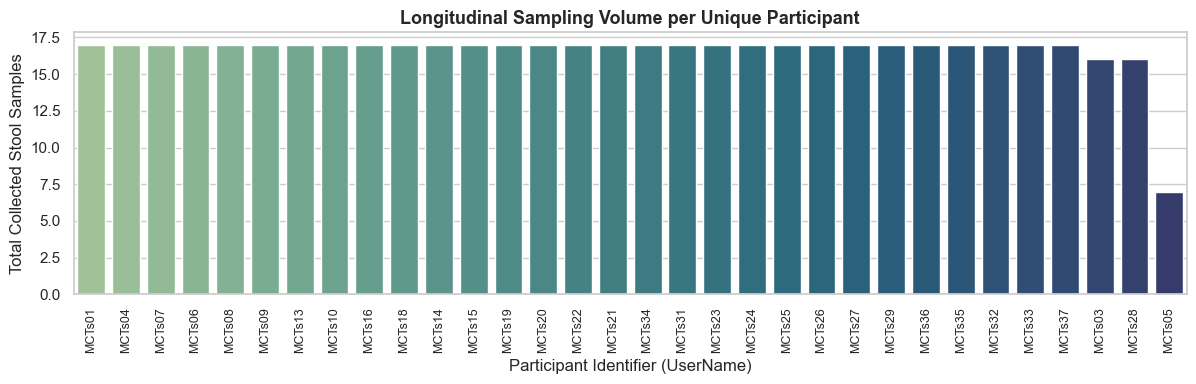

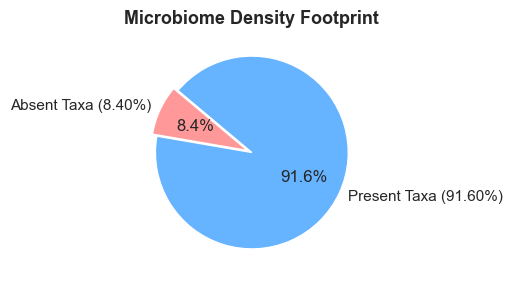

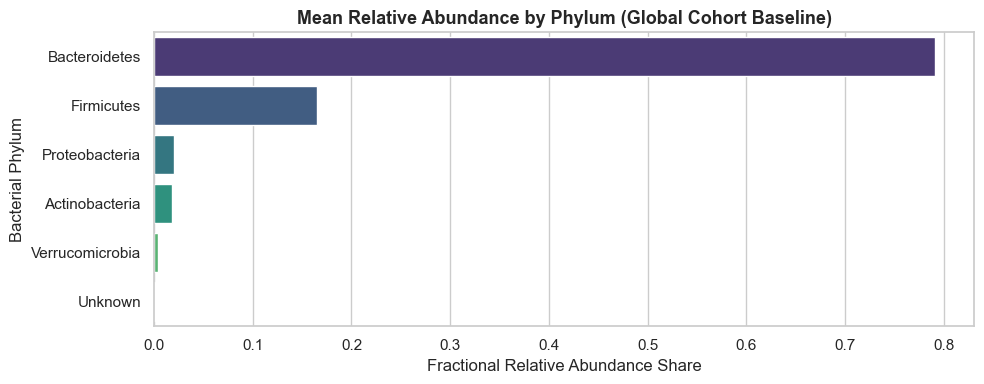

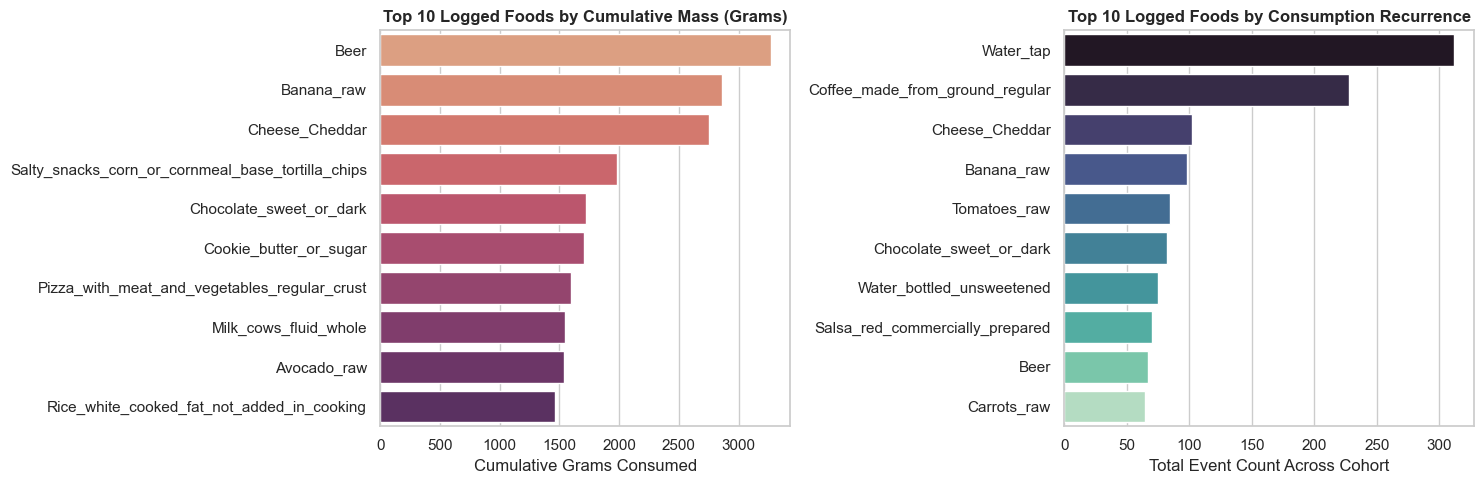

In [3]:
# ============================================================
# 3. MACRO-LEVEL EXPLORATORY DATA ANALYSIS
# ============================================================

# ---------- Plot 1: participant sampling volume ----------
samples_by_user = (
    metadata.groupby("UserName")["#SampleID"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 4))
sampling_plot = pd.DataFrame(
    {"UserName": samples_by_user.index, "SampleCount": samples_by_user.values}
)
sns.barplot(
    data=sampling_plot,
    x="UserName",
    y="SampleCount",
    hue="UserName",
    palette="crest",
    legend=False,
)
plt.xticks(rotation=90, fontsize=9)
plt.title("Longitudinal Sampling Volume per Unique Participant", fontsize=13, weight="bold")
plt.xlabel("Participant Identifier (UserName)")
plt.ylabel("Total Collected Stool Samples")
plt.tight_layout()
plt.show()

# ---------- Plot 2: NORM matrix sparsity ----------
norm_numeric = gut_norm[norm_sample_columns]
total_matrix_cells = int(norm_numeric.size)
zero_matrix_cells = int(norm_numeric.eq(0).sum().sum())
sparsity_ratio = 100 * zero_matrix_cells / total_matrix_cells

plt.figure(figsize=(5, 5))
plt.pie(
    [zero_matrix_cells, total_matrix_cells - zero_matrix_cells],
    labels=[
        f"Absent Taxa ({sparsity_ratio:.2f}%)",
        f"Present Taxa ({100 - sparsity_ratio:.2f}%)",
    ],
    autopct="%1.1f%%",
    colors=["#ff9999", "#66b3ff"],
    startangle=140,
    explode=(0.05, 0),
)
plt.title("Microbiome Density Footprint", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# ---------- Plot 3: cohort phylum landscape ----------
gut_norm_annotated = gut_norm[["#taxonomy"] + norm_sample_columns].copy()
gut_norm_annotated["Phylum"] = gut_norm_annotated["#taxonomy"].apply(
    lambda value: extract_taxonomic_rank(value, "p")
)
gut_norm_annotated["Genus"] = gut_norm_annotated["#taxonomy"].apply(
    lambda value: extract_taxonomic_rank(value, "g")
)
gut_norm_annotated["Mean_Abundance"] = gut_norm_annotated[norm_sample_columns].mean(axis=1)

phylum_profiles = (
    gut_norm_annotated.groupby("Phylum", as_index=False)["Mean_Abundance"]
    .sum()
    .sort_values("Mean_Abundance", ascending=False)
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=phylum_profiles,
    y="Phylum",
    x="Mean_Abundance",
    hue="Phylum",
    palette="viridis",
    legend=False,
)
plt.title("Mean Relative Abundance by Phylum (Global Cohort Baseline)", fontsize=13, weight="bold")
plt.xlabel("Fractional Relative Abundance Share")
plt.ylabel("Bacterial Phylum")
plt.tight_layout()
plt.show()

# ---------- Plot 4: dietary mass and recurrence ----------
food_metrics = (
    diet_df.groupby("Food_Name", as_index=False)
    .agg(Total_Grams=("Grams", "sum"), Consumption_Events=("Grams", "count"))
)
top_mass = food_metrics.nlargest(10, "Total_Grams")
top_frequency = food_metrics.nlargest(10, "Consumption_Events")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=top_mass,
    y="Food_Name",
    x="Total_Grams",
    hue="Food_Name",
    palette="flare",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Top 10 Logged Foods by Cumulative Mass (Grams)", fontsize=12, weight="bold")
axes[0].set_xlabel("Cumulative Grams Consumed")
axes[0].set_ylabel("")

sns.barplot(
    data=top_frequency,
    y="Food_Name",
    x="Consumption_Events",
    hue="Food_Name",
    palette="mako",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Top 10 Logged Foods by Consumption Recurrence", fontsize=12, weight="bold")
axes[1].set_xlabel("Total Event Count Across Cohort")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

# 3. Data quality, outliers, and mathematical validation

Missingness and outliers are audited rather than automatically removed.

### Missing metadata

Auxiliary survey fields may be incomplete even when the longitudinal backbone is intact. The core identifiers (`#SampleID`, `UserName`, `StudyDayNo`) are checked separately because deleting rows for unrelated missing variables can break participant timelines.

### Dietary outliers

The upper IQR threshold is used as a **flagging rule**, not a deletion rule:

$$\text{Upper bound}=Q_3+1.5\times\text{IQR}$$

Large gram values may represent valid meals, beverages, or aggregated diary entries. The most extreme records are printed for contextual review rather than assumed to be errors.

### Compositional constraints

For each sample column:

- NORM values should sum to approximately $1$.
- CLR values should sum to approximately $0$.

The cell reports both pass/fail status and maximum absolute deviation. This is more informative than a Boolean result alone and makes preprocessing failures easier to diagnose.

RUNNING PIPELINE DIAGNOSTICS AND SYSTEM AUDIT

Identified metadata gaps:
  ⚠ Run2.Rerun: 88.35% missing
  ⚠ Medications: 54.32% missing
  ⚠ Dietary.Supp: 33.08% missing
  ⚠ fecal.time: 10.71% missing
  ⚠ Run1.Plate: 10.53% missing
  ⚠ SampleOrder: 10.53% missing
  ⚠ Waist.Circumference: 6.39% missing
  ⚠ Weight.Change: 6.20% missing
  ⚠ fecal.status: 0.75% missing


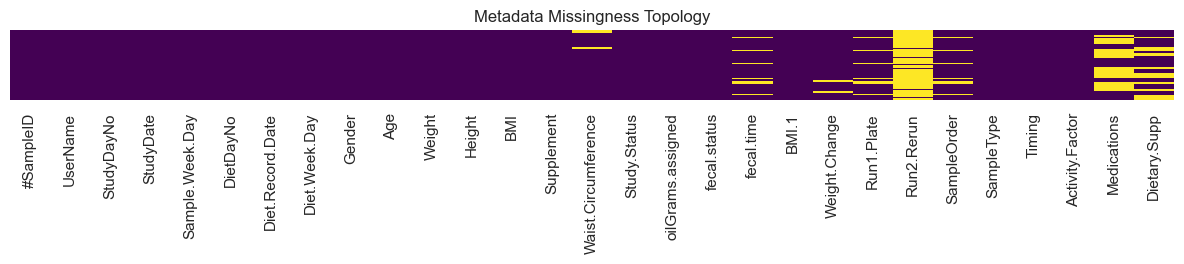


Core longitudinal missing-value counts:


,MissingRows
#SampleID,0
UserName,0
StudyDayNo,0



Calculated IQR upper flagging bound: 77.6 grams
Flagged 441 entries (5.78% of positive events).

Top 10 flagged consumption records for contextual review:


,#SampleID,Food_Name,Grams,SourceFile
5475,MCT.f.0437,Pizza_with_meat_other_than_pepperoni_from_restaurant_or_fast_food_thin_crust,508.934400,MCTs26_food.txt
4738,MCT.f.0383,Taco_or_tostada_with_meat_and_beans,369.063750,MCTs23_food.txt
1082,MCT.f.0091,Pizza_with_meat_and_vegetables_regular_crust,357.120000,MCTs06_food.txt
5481,MCT.f.0438,Beer,347.328000,MCTs26_food.txt
3504,MCT.f.0303,Pizza_with_meat_and_vegetables_thin_crust,330.299200,MCTs18_food.txt
4898,MCT.f.0392,Pizza_with_meat_and_vegetables_prepared_from_frozen_thick_crust,323.059500,MCTs24_food.txt
5023,MCT.f.0400,Rice_fried_with_pork,301.603500,MCTs24_food.txt
266,MCT.f.0013,Margarita,288.820800,MCTs01_food.txt
560,MCT.f.0044,Pizza_cheese_with_vegetables_prepared_from_frozen_thick_crust,287.228125,MCTs03_food.txt
1405,MCT.f.0114,Pizza_with_cheese_and_extra_vegetables_regular_crust,286.854400,MCTs07_food.txt


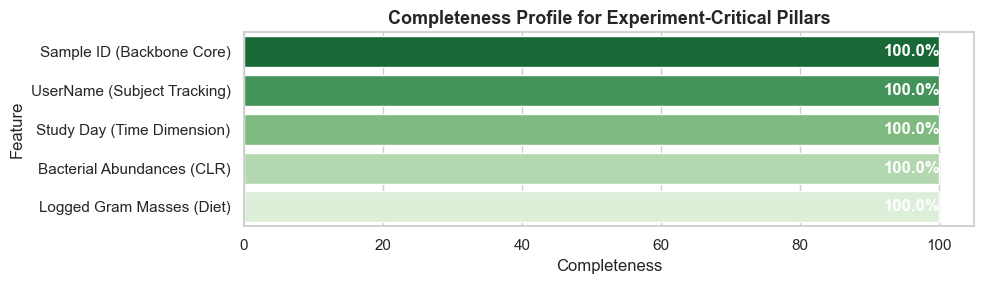


Non-positive gram records retained: 0

Mathematical constraint validation:
  NORM columns sum to 1 within 1e-3: True
  Maximum absolute NORM deviation: 1.46549e-14
  CLR columns sum to 0 within 1e-2: True
  Maximum absolute CLR deviation: 1.98952e-13


In [4]:
# ============================================================
# 4. DATA-QUALITY AUDIT AND BIOLOGICAL CONSTRAINT CHECKS
# ============================================================

print("=" * 60)
print("RUNNING PIPELINE DIAGNOSTICS AND SYSTEM AUDIT")
print("=" * 60)

# ---------- Missingness audit ----------
missing_fractions = metadata.isna().mean().mul(100)
problematic_columns = missing_fractions.loc[missing_fractions > 0].sort_values(ascending=False)

if problematic_columns.empty:
    print("\n✔ No missing metadata values were detected.")
else:
    print("\nIdentified metadata gaps:")
    for column_name, percentage in problematic_columns.items():
        print(f"  ⚠ {column_name}: {percentage:.2f}% missing")

    plt.figure(figsize=(12, 2.8))
    sns.heatmap(metadata.isna(), cbar=False, cmap="viridis", yticklabels=False)
    plt.title("Metadata Missingness Topology")
    plt.tight_layout()
    plt.show()

core_missing = metadata[["#SampleID", "UserName", "StudyDayNo"]].isna().sum()
print("\nCore longitudinal missing-value counts:")
display(core_missing.rename("MissingRows").to_frame())

# ---------- Dietary outlier audit ----------
q25, q75 = diet_df["Grams"].quantile([0.25, 0.75])
computed_iqr = q75 - q25
diet_upper_limit = q75 + 1.5 * computed_iqr
flagged_outliers = diet_df.loc[diet_df["Grams"] > diet_upper_limit].copy()

print(f"\nCalculated IQR upper flagging bound: {diet_upper_limit:.1f} grams")
print(
    f"Flagged {len(flagged_outliers)} entries "
    f"({100 * len(flagged_outliers) / len(diet_df):.2f}% of positive events)."
)
print("\nTop 10 flagged consumption records for contextual review:")
display(
    flagged_outliers.nlargest(10, "Grams")[["#SampleID", "Food_Name", "Grams", "SourceFile"]]
)

# ---------- Critical-field completeness ----------
clr_numeric = gut_clr[clr_sample_columns]
critical_completeness = pd.DataFrame(
    {
        "Feature": [
            "Sample ID (Backbone Core)",
            "UserName (Subject Tracking)",
            "Study Day (Time Dimension)",
            "Bacterial Abundances (CLR)",
            "Logged Gram Masses (Diet)",
        ],
        "Completeness": [
            100 * metadata["#SampleID"].notna().mean(),
            100 * metadata["UserName"].notna().mean(),
            100 * metadata["StudyDayNo"].notna().mean(),
            100 * clr_numeric.notna().to_numpy().mean(),
            100 * diet_df["Grams"].notna().mean(),
        ],
    }
)

plt.figure(figsize=(10, 3))
axis = sns.barplot(
    data=critical_completeness,
    x="Completeness",
    y="Feature",
    hue="Feature",
    palette="Greens_r",
    legend=False,
)
for patch, value in zip(axis.patches, critical_completeness["Completeness"]):
    axis.text(
        max(value - 8, 1),
        patch.get_y() + patch.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        color="white" if value >= 20 else "black",
        weight="bold",
    )
plt.xlim(0, 105)
plt.title("Completeness Profile for Experiment-Critical Pillars", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# ---------- Physical and compositional constraints ----------
nonpositive_grams_count = int(diet_df["Grams"].le(0).sum())
print(f"\nNon-positive gram records retained: {nonpositive_grams_count}")

norm_column_sums = norm_numeric.sum(axis=0, skipna=False)
clr_column_sums = clr_numeric.sum(axis=0, skipna=False)

norm_max_deviation = float((norm_column_sums - 1.0).abs().max())
clr_max_deviation = float(clr_column_sums.abs().max())
norm_is_valid = bool(np.isclose(norm_column_sums, 1.0, atol=1e-3, equal_nan=False).all())
clr_is_valid = bool(np.isclose(clr_column_sums, 0.0, atol=1e-2, equal_nan=False).all())

print("\nMathematical constraint validation:")
print(f"  NORM columns sum to 1 within 1e-3: {norm_is_valid}")
print(f"  Maximum absolute NORM deviation: {norm_max_deviation:.6g}")
print(f"  CLR columns sum to 0 within 1e-2: {clr_is_valid}")
print(f"  Maximum absolute CLR deviation: {clr_max_deviation:.6g}")

# 4. Compositional data and sample-level ecological indices

Relative abundances are compositional: increasing one component necessarily decreases the relative share of others even when their absolute cell counts do not change. The CLR representation reduces this fixed-sum artifact:

$$\operatorname{CLR}(x_i)=\ln\left(\frac{x_i}{g(x)}\right),$$

where $g(x)$ is the geometric mean of all components in the sample. Temporal change is represented as

$$\Delta\operatorname{CLR}=\operatorname{CLR}_{T}-\operatorname{CLR}_{T-1}.$$

For every microbiome sample, the notebook calculates:

- active taxon, family, and phylum counts;
- Shannon entropy at taxon and family levels;
- sample-level CLR variance;
- a guarded Silhouette score using family labels and CLR abundance as the feature.

The Silhouette calculation is attempted only when there are at least two valid labels and fewer labels than observations. This prevents invalid label configurations from terminating the notebook. Because the Silhouette feature space is one-dimensional and based only on CLR abundance, it should be interpreted as an exploratory structural index rather than a complete measure of phylogenetic organization.

In [5]:
# ============================================================
# 5. TAXONOMY PARSING AND SAMPLE-LEVEL ECOLOGICAL INDICES
# ============================================================

print("=" * 60)
print("PARSING TAXONOMY AND COMPUTING SAMPLE-LEVEL INDICES")
print("=" * 60)


def parse_taxonomy_hierarchy(taxonomy: object) -> pd.Series:
    """Parse all standard taxonomic ranks into named columns."""
    rank_names = {
        "k": "Kingdom",
        "p": "Phylum",
        "c": "Class",
        "o": "Order",
        "f": "Family",
        "g": "Genus",
        "s": "Species",
    }
    parsed = {column_name: "Unknown" for column_name in rank_names.values()}
    for part in str(taxonomy).split(";"):
        if "__" not in part:
            continue
        level, name = part.split("__", 1)
        level, name = level.strip(), name.strip()
        if level in rank_names and name:
            parsed[rank_names[level]] = name
    return pd.Series(parsed)


taxa_metadata = gut_clr[["#taxonomy"]].drop_duplicates().copy()
taxa_parsed = taxa_metadata["#taxonomy"].apply(parse_taxonomy_hierarchy)
taxa_extended = pd.concat([taxa_metadata.reset_index(drop=True), taxa_parsed.reset_index(drop=True)], axis=1)

print("\nTaxonomy preview:")
display(taxa_extended[["#taxonomy", "Phylum", "Family", "Genus", "Species"]].head(5))

# Convert both matrices to long form using only their shared sample columns.
clr_long = gut_clr[["#taxonomy"] + common_microbiome_samples].melt(
    id_vars="#taxonomy", var_name="#SampleID", value_name="CLR"
)
norm_long = gut_norm[["#taxonomy"] + common_microbiome_samples].melt(
    id_vars="#taxonomy", var_name="#SampleID", value_name="NORM"
)

integrated_microbiome = (
    clr_long.merge(norm_long, on=["#taxonomy", "#SampleID"], how="inner")
    .merge(taxa_extended, on="#taxonomy", how="left")
)

sample_index_records = []
for sample_id, group in integrated_microbiome.groupby("#SampleID", sort=False):
    present = group.loc[group["NORM"].gt(0) & group["NORM"].notna()].copy()
    if present.empty:
        continue

    num_taxa = int(present["#taxonomy"].nunique())
    num_families = int(present["Family"].nunique())
    num_phyla = int(present["Phylum"].nunique())

    taxon_entropy = float(entropy(present["NORM"].to_numpy()))
    family_abundance = present.groupby("Family")["NORM"].sum().to_numpy()
    family_entropy = float(entropy(family_abundance))

    # Silhouette score requires 2 <= number of labels <= number of observations - 1.
    structural_subset = present.dropna(subset=["CLR", "Family"]).copy()
    family_labels = structural_subset["Family"].astype(str)
    n_labels = family_labels.nunique()
    silhouette = np.nan
    if 2 <= n_labels < len(structural_subset):
        try:
            silhouette = float(
                silhouette_score(
                    structural_subset[["CLR"]].to_numpy(),
                    family_labels.to_numpy(),
                )
            )
        except ValueError:
            silhouette = np.nan

    sample_index_records.append(
        {
            "#SampleID": sample_id,
            "NumMicroorganisms": num_taxa,
            "NumFamilies": num_families,
            "NumPhyla": num_phyla,
            "EntropyMicro": taxon_entropy,
            "EntropyFamily": family_entropy,
            "StructureSilhouette": silhouette,
            "SampleVariance": float(present["CLR"].var()),
        }
    )

indexes_df = pd.DataFrame(sample_index_records)
if indexes_df.empty:
    raise ValueError("No sample-level ecological indices could be calculated.")

diversity_df = (
    metadata[["#SampleID", "UserName", "StudyDayNo"]]
    .merge(indexes_df, on="#SampleID", how="inner")
    .sort_values(["UserName", "StudyDayNo"])
)

print(f"\n✔ Ecological indices calculated for {len(indexes_df)} microbiome profiles.")
display(indexes_df.head())

PARSING TAXONOMY AND COMPUTING SAMPLE-LEVEL INDICES

Taxonomy preview:


,#taxonomy,Phylum,Family,Genus,Species
0,k__Bacteria;NA;NA;NA;NA;NA;NA,Unknown,Unknown,Unknown,Unknown
1,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;NA,Actinobacteria,Bifidobacteriaceae,Bifidobacterium,Unknown
2,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bifidobacterium adolescentis,Actinobacteria,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium adolescentis
3,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bifidobacterium bifidum,Actinobacteria,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium bifidum
4,k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bifidobacterium catenulatum,Actinobacteria,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium catenulatum



✔ Ecological indices calculated for 483 microbiome profiles.


,#SampleID,NumMicroorganisms,NumFamilies,NumPhyla,EntropyMicro,EntropyFamily,StructureSilhouette,SampleVariance
0,MCT.f.0002,214,29,6,2.862657,1.305867,-0.754633,5.259094
1,MCT.f.0003,208,29,6,3.522780,2.129824,-0.764816,5.190030
2,MCT.f.0004,213,30,6,3.031031,1.657214,-0.776679,4.782778
3,MCT.f.0005,207,29,6,2.974028,1.456498,-0.777462,4.483868
4,MCT.f.0006,209,28,6,3.081194,1.645557,-0.792304,4.395520


# 5. Longitudinal pairing, ecosystem deltas, and taxon-level transitions

The temporal backbone is built independently for each participant. Each current sample is paired with that participant’s immediately preceding sample, and `DayGap` records the difference in study-day numbers.

By default, `REQUIRE_CONSECUTIVE_DAYS = True`, so only transitions with `DayGap == 1` are analyzed. This aligns the implementation with the stated T−1 → T design. Set the flag to `False` only when the estimand should be change between consecutive **observed** samples regardless of calendar gaps.

For each valid transition, the notebook computes changes in richness, entropy, Silhouette structure, and CLR variance. NORM presence/absence vectors are compared to count taxa that appeared or disappeared overnight.

A taxon-level transition table is created in parallel with current CLR, previous CLR, `DeltaCLR`, and absolute change. This explicit table replaces the undefined `temporal_df` dependency that caused the original final experiment cell to fail.

In [6]:
# ============================================================
# 6. TEMPORAL BACKBONE, ECOSYSTEM DELTAS, AND TAXON DELTAS
# ============================================================

REQUIRE_CONSECUTIVE_DAYS = True

backbone = metadata[["#SampleID", "UserName", "StudyDayNo"]].copy()
backbone = backbone.sort_values(["UserName", "StudyDayNo", "#SampleID"])
backbone["PrevSampleID"] = backbone.groupby("UserName")["#SampleID"].shift(1)
backbone["PrevStudyDayNo"] = backbone.groupby("UserName")["StudyDayNo"].shift(1)
backbone["DayGap"] = backbone["StudyDayNo"] - backbone["PrevStudyDayNo"]

available_samples = set(indexes_df["#SampleID"])
temporal_pairs = backbone.dropna(subset=["PrevSampleID"]).copy()
temporal_pairs = temporal_pairs.loc[
    temporal_pairs["#SampleID"].isin(available_samples)
    & temporal_pairs["PrevSampleID"].isin(available_samples)
].copy()

all_valid_pair_count = len(temporal_pairs)
if REQUIRE_CONSECUTIVE_DAYS:
    temporal_pairs = temporal_pairs.loc[temporal_pairs["DayGap"].eq(1)].copy()

if temporal_pairs.empty:
    raise ValueError("No valid longitudinal sample pairs remain after temporal filtering.")

current_indices = indexes_df.add_suffix("_T")
previous_indices = indexes_df.add_suffix("_Tminus1")

temporal_engine = (
    temporal_pairs.merge(
        current_indices,
        left_on="#SampleID",
        right_on="#SampleID_T",
        how="inner",
    )
    .merge(
        previous_indices,
        left_on="PrevSampleID",
        right_on="#SampleID_Tminus1",
        how="inner",
    )
)

# Richness, diversity, structure, and variance changes.
temporal_engine["Delta_NumMicroorganisms"] = (
    temporal_engine["NumMicroorganisms_T"]
    - temporal_engine["NumMicroorganisms_Tminus1"]
)
temporal_engine["Delta_NumFamilies"] = (
    temporal_engine["NumFamilies_T"] - temporal_engine["NumFamilies_Tminus1"]
)
temporal_engine["Delta_EntropyMicro"] = (
    temporal_engine["EntropyMicro_T"] - temporal_engine["EntropyMicro_Tminus1"]
)
temporal_engine["Delta_EntropyFamily"] = (
    temporal_engine["EntropyFamily_T"] - temporal_engine["EntropyFamily_Tminus1"]
)
temporal_engine["Delta_Silhouette"] = (
    temporal_engine["StructureSilhouette_T"]
    - temporal_engine["StructureSilhouette_Tminus1"]
)
temporal_engine["Delta_Variance"] = (
    temporal_engine["SampleVariance_T"] - temporal_engine["SampleVariance_Tminus1"]
)

# Presence/absence turnover using the NORM matrix.
norm_wide = gut_norm.set_index("#taxonomy")[common_microbiome_samples]
turnover_records = []
for row in temporal_engine[["#SampleID", "PrevSampleID"]].itertuples(index=False):
    current_sample, previous_sample = row
    previous_presence = norm_wide[previous_sample].gt(0)
    current_presence = norm_wide[current_sample].gt(0)
    turnover_records.append(
        {
            "#SampleID": current_sample,
            "NumGainedMicro": int((~previous_presence & current_presence).sum()),
            "NumGoneMicro": int((previous_presence & ~current_presence).sum()),
        }
    )

temporal_engine = temporal_engine.merge(
    pd.DataFrame(turnover_records), on="#SampleID", how="left"
)

# Explicit taxon-level temporal table used by the targeted experiments.
current_clr = clr_long.rename(columns={"CLR": "CurrentCLR"})
previous_clr = clr_long.rename(
    columns={"#SampleID": "PrevSampleID", "CLR": "PreviousCLR"}
)

temporal_taxa = (
    temporal_pairs[["#SampleID", "PrevSampleID", "UserName", "StudyDayNo", "DayGap"]]
    .merge(current_clr, on="#SampleID", how="inner")
    .merge(previous_clr, on=["PrevSampleID", "#taxonomy"], how="inner")
)
temporal_taxa["DeltaCLR"] = temporal_taxa["CurrentCLR"] - temporal_taxa["PreviousCLR"]
temporal_taxa["AbsDeltaCLR"] = temporal_taxa["DeltaCLR"].abs()

stability_summary = (
    temporal_taxa.groupby("UserName", as_index=False)["AbsDeltaCLR"]
    .mean()
    .rename(columns={"AbsDeltaCLR": "MeanAbsoluteChange"})
)

print(f"Candidate observed-sample pairs: {all_valid_pair_count}")
print(f"Pairs retained for analysis: {len(temporal_engine)}")
print(f"Taxon-level transition rows: {len(temporal_taxa):,}")
display(
    temporal_engine[
        [
            "#SampleID",
            "PrevSampleID",
            "UserName",
            "DayGap",
            "Delta_NumMicroorganisms",
            "Delta_EntropyMicro",
            "NumGainedMicro",
            "NumGoneMicro",
        ]
    ].head()
)

Candidate observed-sample pairs: 352
Pairs retained for analysis: 350
Taxon-level transition rows: 78,050


,#SampleID,PrevSampleID,UserName,DayGap,Delta_NumMicroorganisms,Delta_EntropyMicro,NumGainedMicro,NumGoneMicro
0,MCT.f.0003,MCT.f.0002,MCTs01,1.0,-6,0.660123,1,7
1,MCT.f.0004,MCT.f.0003,MCTs01,1.0,5,-0.491749,6,1
2,MCT.f.0005,MCT.f.0004,MCTs01,1.0,-6,-0.057004,1,7
3,MCT.f.0006,MCT.f.0005,MCTs01,1.0,2,0.107166,6,4
4,MCT.f.0007,MCT.f.0006,MCTs01,1.0,3,-0.053910,5,2


# 6. Dietary exposure integration and participant-balanced summaries

Food consumption logged at the previous time point is linked to the microbiome transition ending at the current sample. Multiple diary rows matching the same broad food category within one previous sample are summed before merging, preventing duplicate weighting of the same microbiome transition.

The ten exposure categories from the original notebook are retained:

`Yogurt`, `Cheese`, `Coffee`, `Egg`, `Banana`, `Tomato`, `Bread`, `Apple`, `Chicken`, and `Chocolate`.

Two aggregation levels are produced:

1. `user_food_profile` — the mean response for each participant and food category.
2. `global_food_impact` — the mean of participant-level means.

The second level prevents participants with more valid observations from dominating the cohort summary. The output includes gained/gone taxa, richness deltas, entropy deltas, variance change, and structural change, along with exposure and participant coverage for each food.

In [7]:
# ============================================================
# 7. DIETARY EXPOSURE INTEGRATION AND PARTICIPANT BALANCING
# ============================================================

TARGET_FOODS = [
    "Yogurt",
    "Cheese",
    "Coffee",
    "Egg",
    "Banana",
    "Tomato",
    "Bread",
    "Apple",
    "Chicken",
    "Chocolate",
]

# Food events belong to the previous time point in each T-1 -> T transition.
diet_previous = diet_df.rename(columns={"#SampleID": "PrevSampleID"}).copy()
experiment_frames = []
food_exposure_counts = []

for food_name in TARGET_FOODS:
    matching_events = diet_previous.loc[food_match_mask(diet_previous, food_name)].copy()
    if matching_events.empty:
        print(f"⚠ No diary rows matched food category: {food_name}")
        continue

    # One exposure row per previous sample avoids duplicate weighting.
    grouped_exposure = (
        matching_events.groupby("PrevSampleID", as_index=False)["Grams"]
        .sum()
        .assign(FoodType=food_name)
    )
    merged_exposure = temporal_engine.merge(
        grouped_exposure, on="PrevSampleID", how="inner"
    )
    if merged_exposure.empty:
        print(f"⚠ {food_name} matched diary rows but no valid temporal transitions.")
        continue

    experiment_frames.append(merged_exposure)
    food_exposure_counts.append(
        {
            "FoodType": food_name,
            "MatchedTransitions": len(merged_exposure),
            "Participants": merged_exposure["UserName"].nunique(),
        }
    )

if not experiment_frames:
    raise ValueError("No target-food exposures could be linked to microbiome transitions.")

experiment_pool = pd.concat(experiment_frames, ignore_index=True)
exposure_coverage = pd.DataFrame(food_exposure_counts)

metrics_list = [
    "NumGainedMicro",
    "NumGoneMicro",
    "Delta_NumMicroorganisms",
    "Delta_NumFamilies",
    "Delta_Variance",
    "Delta_EntropyMicro",
    "Delta_EntropyFamily",
    "Delta_Silhouette",
]

user_food_profile = (
    experiment_pool.groupby(["UserName", "FoodType"], as_index=False)[metrics_list]
    .mean()
)
global_food_impact = (
    user_food_profile.groupby("FoodType", as_index=False)[metrics_list]
    .mean()
)

print("\nExposure coverage:")
display(exposure_coverage)
print("\nGlobal averages (mean of participant-level means):")
display(
    global_food_impact[
        [
            "FoodType",
            "Delta_NumMicroorganisms",
            "Delta_NumFamilies",
            "Delta_EntropyMicro",
            "Delta_Silhouette",
        ]
    ].round(4)
)


Exposure coverage:


,FoodType,MatchedTransitions,Participants
0,Yogurt,60,18
1,Cheese,229,31
2,Coffee,225,24
3,Egg,135,27
4,Banana,87,25
5,Tomato,143,29
6,Bread,180,30
7,Apple,78,22
8,Chicken,143,28
9,Chocolate,159,29



Global averages (mean of participant-level means):


,FoodType,Delta_NumMicroorganisms,Delta_NumFamilies,Delta_EntropyMicro,Delta_Silhouette
0,Apple,0.2285,-0.3298,0.0350,0.0065
1,Banana,1.1996,0.2900,-0.0027,-0.0003
2,Bread,0.3426,-0.0232,-0.0199,0.0012
3,Cheese,-0.7503,-0.1424,-0.0040,-0.0015
4,Chicken,1.9863,0.1352,0.0038,0.0026
5,Chocolate,-0.9095,-0.1598,-0.0104,0.0036
6,Coffee,0.3141,0.0627,-0.0058,-0.0035
7,Egg,0.7729,-0.0473,-0.0402,-0.0036
8,Tomato,0.9000,-0.0527,0.0300,-0.0014
9,Yogurt,-1.8850,0.1778,-0.0507,-0.0075


# 7. Ecosystem-level visualization suite

The visualization suite preserves the original four ecosystem outputs while clarifying what each plot estimates:

1. **Richness shifts** — mean change in active taxa and families after each food exposure, with confidence intervals across participant-level summaries.
2. **Entropy shifts** — mean taxon- and family-level Shannon changes.
3. **Turnover distributions** — participant-level distributions of gained and gone taxa.
4. **Diversity–volatility coordination map** — participant-food points positioned by entropy change and CLR-variance change.

Values to the right of zero indicate increases; values to the left indicate decreases. Confidence intervals and boxplots describe heterogeneity and should not be interpreted as proof of causality. The scatter plot is especially useful for revealing foods whose cohort mean masks strongly different participant-level responses.

GENERATING LONGITUDINAL ECOSYSTEM VISUALIZATIONS


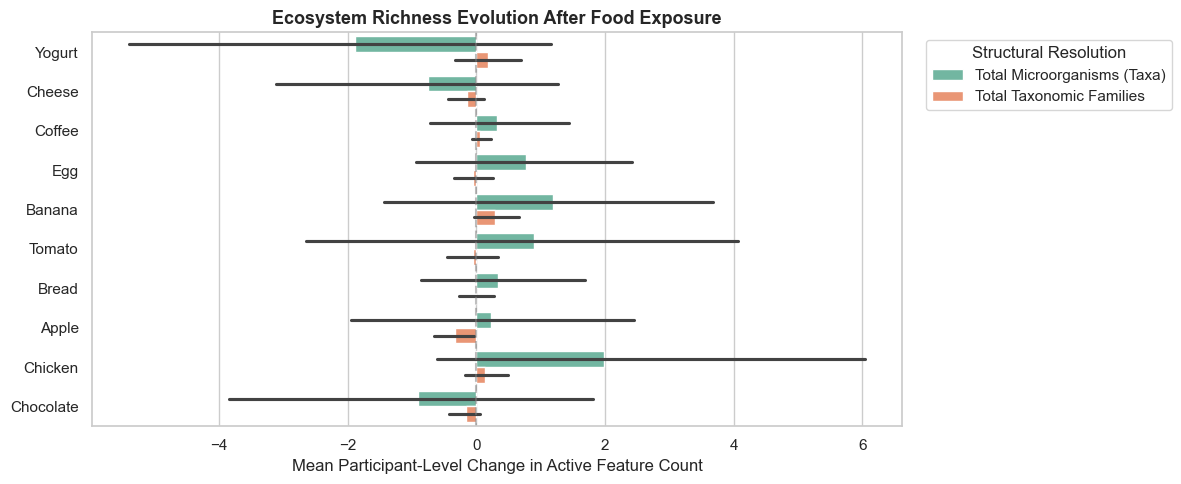

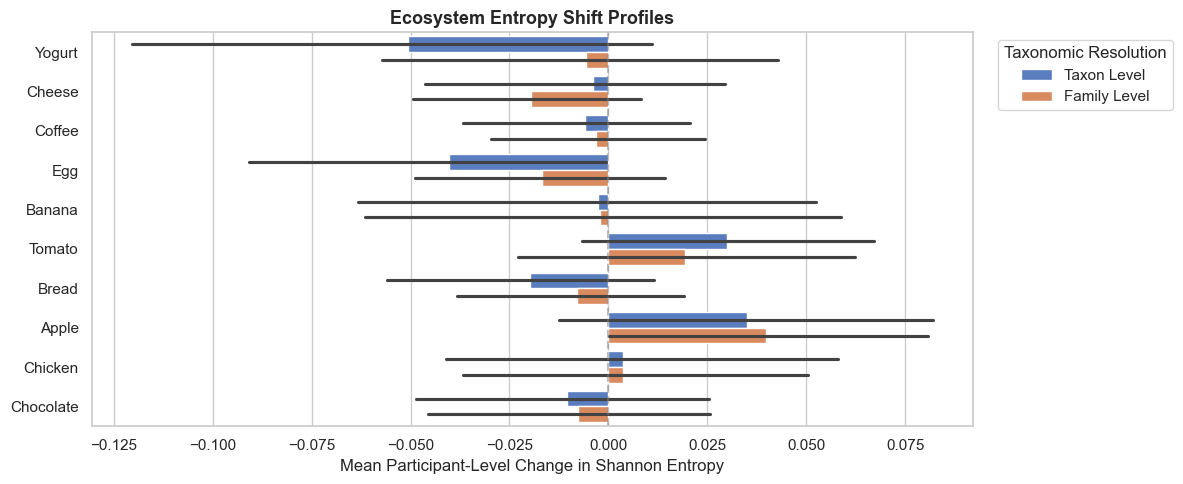

c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\tttgg\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vert

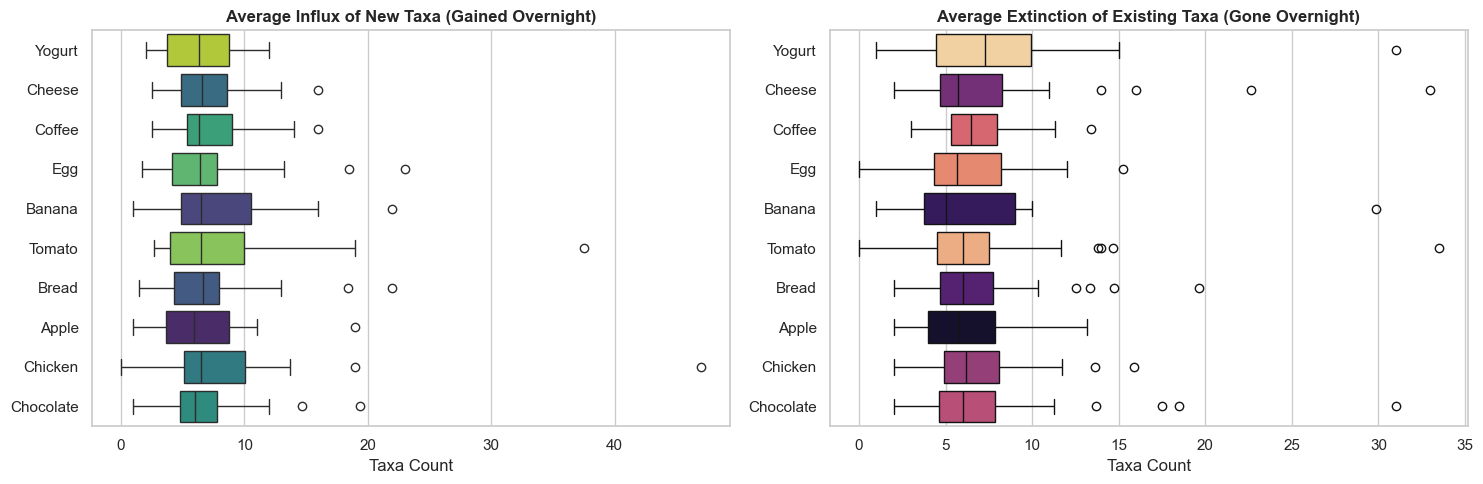

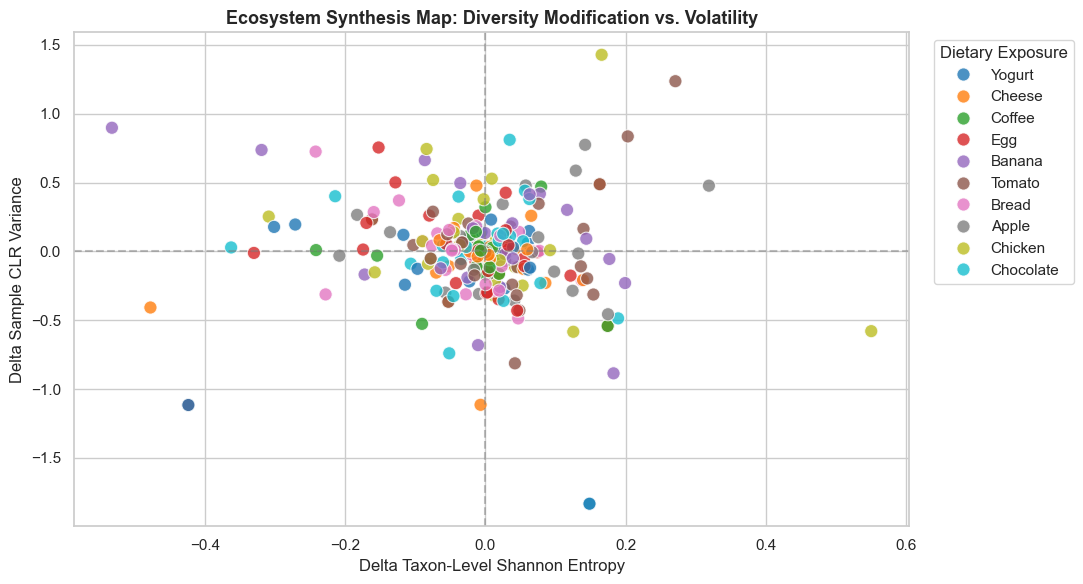

In [8]:
# ============================================================
# 8. PUBLICATION-GRADE ECOSYSTEM VISUALIZATIONS
# ============================================================

print("=" * 60)
print("GENERATING LONGITUDINAL ECOSYSTEM VISUALIZATIONS")
print("=" * 60)

food_order = [food for food in TARGET_FOODS if food in user_food_profile["FoodType"].unique()]

# ---------- Plot 1: richness shifts ----------
melted_richness = user_food_profile.melt(
    id_vars=["UserName", "FoodType"],
    value_vars=["Delta_NumMicroorganisms", "Delta_NumFamilies"],
    var_name="Level",
    value_name="CountShift",
)
melted_richness["Level"] = melted_richness["Level"].replace(
    {
        "Delta_NumMicroorganisms": "Total Microorganisms (Taxa)",
        "Delta_NumFamilies": "Total Taxonomic Families",
    }
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=melted_richness,
    x="CountShift",
    y="FoodType",
    hue="Level",
    order=food_order,
    errorbar=("ci", 95),
    palette="Set2",
)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.title("Ecosystem Richness Evolution After Food Exposure", fontsize=13, weight="bold")
plt.xlabel("Mean Participant-Level Change in Active Feature Count")
plt.ylabel("")
plt.legend(title="Structural Resolution", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- Plot 2: entropy shifts ----------
melted_entropy = user_food_profile.melt(
    id_vars=["UserName", "FoodType"],
    value_vars=["Delta_EntropyMicro", "Delta_EntropyFamily"],
    var_name="Level",
    value_name="EntropyShift",
)
melted_entropy["Level"] = melted_entropy["Level"].replace(
    {
        "Delta_EntropyMicro": "Taxon Level",
        "Delta_EntropyFamily": "Family Level",
    }
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=melted_entropy,
    x="EntropyShift",
    y="FoodType",
    hue="Level",
    order=food_order,
    errorbar=("ci", 95),
    palette="muted",
)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.title("Ecosystem Entropy Shift Profiles", fontsize=13, weight="bold")
plt.xlabel("Mean Participant-Level Change in Shannon Entropy")
plt.ylabel("")
plt.legend(title="Taxonomic Resolution", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- Plot 3: gained/gone turnover distributions ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(
    data=user_food_profile,
    x="NumGainedMicro",
    y="FoodType",
    order=food_order,
    hue="FoodType",
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Average Influx of New Taxa (Gained Overnight)", fontsize=12, weight="bold")
axes[0].set_xlabel("Taxa Count")
axes[0].set_ylabel("")

sns.boxplot(
    data=user_food_profile,
    x="NumGoneMicro",
    y="FoodType",
    order=food_order,
    hue="FoodType",
    palette="magma",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Average Extinction of Existing Taxa (Gone Overnight)", fontsize=12, weight="bold")
axes[1].set_xlabel("Taxa Count")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

# ---------- Plot 4: diversity-versus-volatility map ----------
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=user_food_profile,
    x="Delta_EntropyMicro",
    y="Delta_Variance",
    hue="FoodType",
    hue_order=food_order,
    palette="tab10",
    s=90,
    alpha=0.8,
)
plt.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", alpha=0.5)
plt.title("Ecosystem Synthesis Map: Diversity Modification vs. Volatility", fontsize=13, weight="bold")
plt.xlabel("Delta Taxon-Level Shannon Entropy")
plt.ylabel("Delta Sample CLR Variance")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Dietary Exposure")
plt.tight_layout()
plt.show()

# 8. Targeted food–taxon experiment design

The final code cell repairs the original non-runnable targeted experiment by explicitly defining every required input: food exposures, taxon-level transitions, diversity data, stability summaries, and target taxa.

Candidate bacterial patterns include `Bifidobacterium`, `Faecalibacterium`, `Akkermansia`, `Bacteroides`, `Prevotella`, and `Lactobacillus`. Candidates absent from the taxonomy table are reported and skipped.

For each food and taxon pattern, all matched taxonomy rows are first averaged within a participant transition. This prevents broad patterns such as `Bacteroides` from receiving extra weight simply because they match many species-level rows. The summary table reports:

- paired transition count (`N`);
- participant count (`NUsers`);
- mean, median, and standard deviation of `DeltaCLR`;
- participant-balanced mean `DeltaCLR`.

The visual outputs include the original horizontal association ranking, a targeted heatmap, one participant’s Shannon-diversity trajectory, and cohort-level temporal volatility.

Target taxa found: ['Bifidobacterium', 'Faecalibacterium', 'Akkermansia', 'Bacteroides', 'Prevotella', 'Lactobacillus']

Targeted food-taxon results:


,Food,Taxon,N,NUsers,MeanDeltaCLR,MedianDeltaCLR,StdDeltaCLR,UserBalancedMeanDeltaCLR
0,Yogurt,Faecalibacterium,60,18,0.1998,0.1312,1.0320,0.2192
1,Tomato,Akkermansia,143,29,0.1337,0.0795,1.0270,0.1450
2,Banana,Lactobacillus,87,25,0.0926,-0.0028,0.9386,0.1859
3,Chocolate,Akkermansia,159,29,0.0838,0.0556,1.1678,0.0519
4,Apple,Faecalibacterium,78,22,0.0835,0.0380,0.8339,0.0655
5,Chocolate,Prevotella,159,29,0.0590,0.0823,0.5095,0.1346
6,Egg,Akkermansia,135,27,0.0577,0.0556,1.0280,0.0589
7,Coffee,Faecalibacterium,225,24,0.0442,0.0406,1.0089,0.1068
8,Chicken,Faecalibacterium,143,28,0.0391,0.0253,1.1718,0.0931
9,Tomato,Bifidobacterium,143,29,0.0388,0.1119,0.7499,0.0024


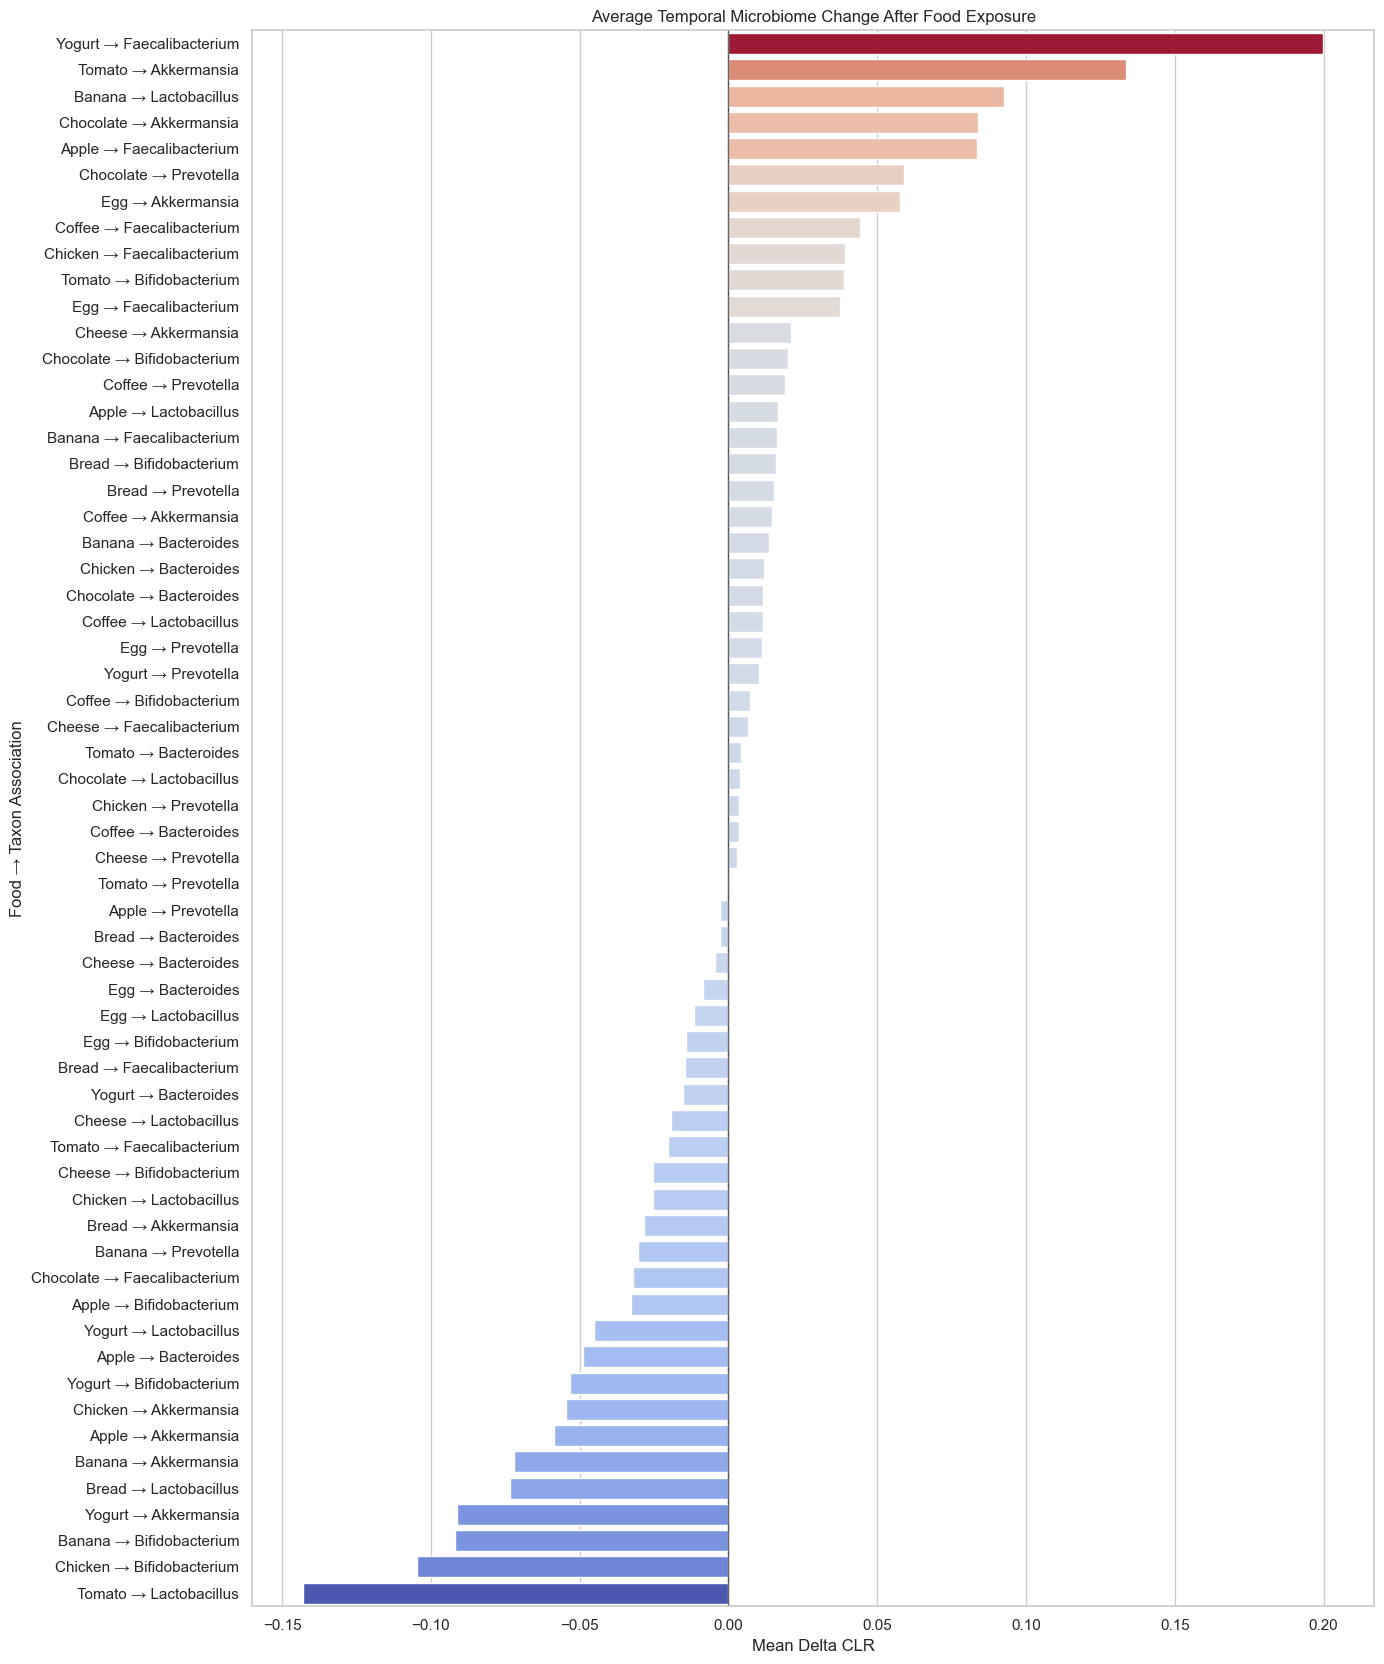

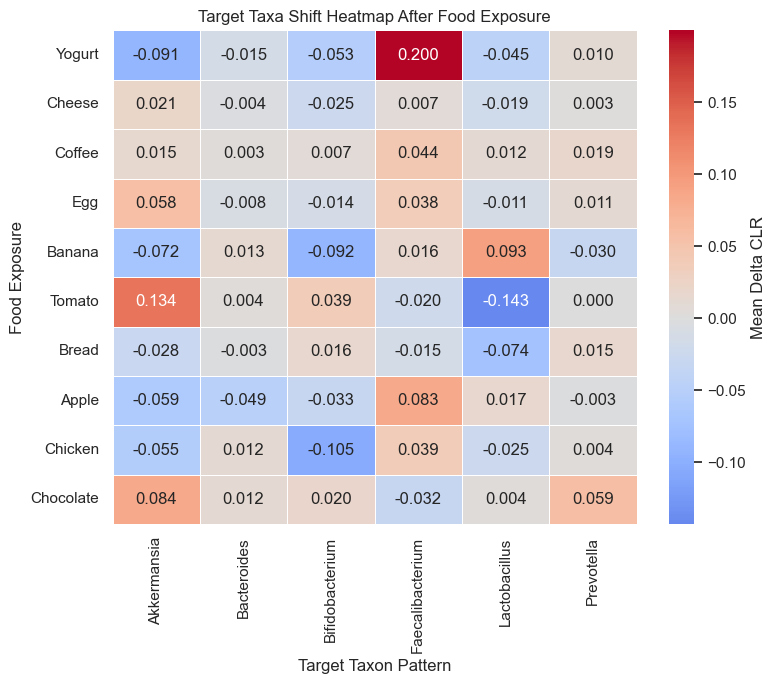

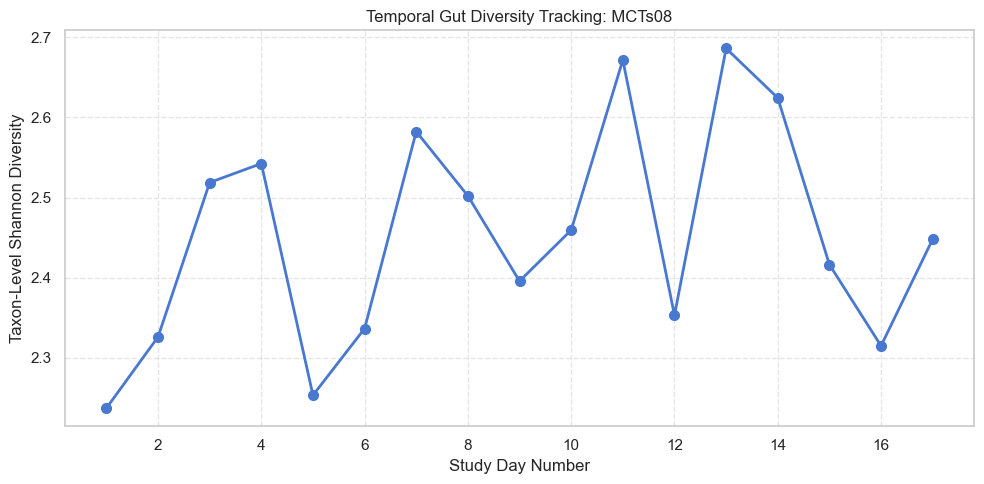

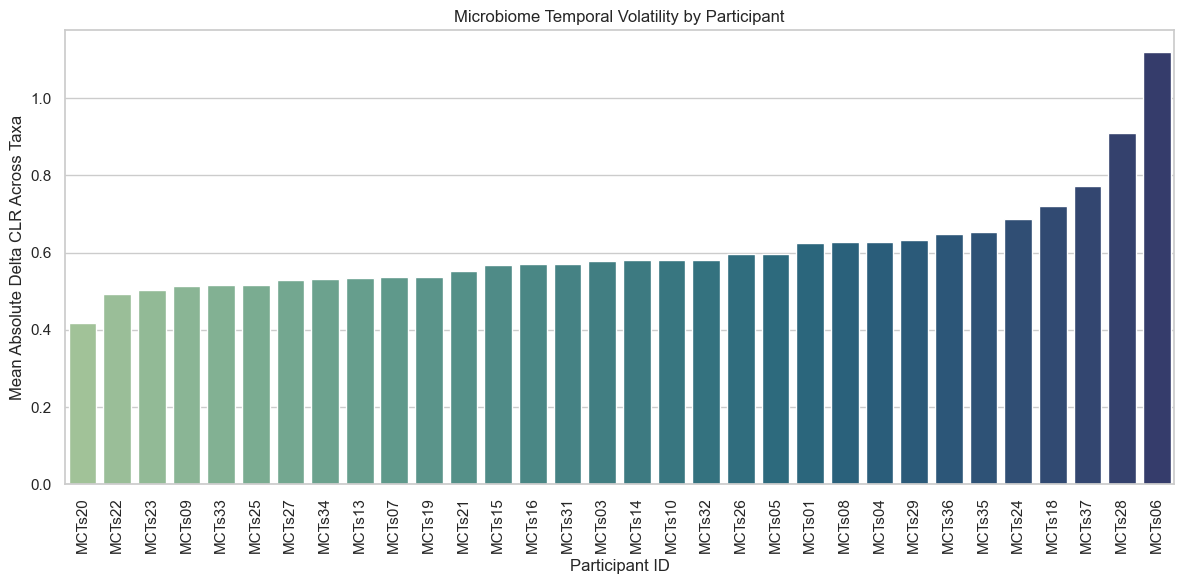


All analyses and visualizations completed successfully.


In [9]:
# ============================================================
# 9. TARGETED FOOD -> TAXON EXPERIMENTS AND FINAL VISUALIZATIONS
# ============================================================

TARGET_TAXON_CANDIDATES = [
    "Bifidobacterium",
    "Faecalibacterium",
    "Akkermansia",
    "Bacteroides",
    "Prevotella",
    "Lactobacillus",
]

available_taxonomy = gut_clr["#taxonomy"].astype(str)
target_taxa = [
    taxon
    for taxon in TARGET_TAXON_CANDIDATES
    if available_taxonomy.str.contains(re.escape(taxon), case=False, na=False).any()
]
missing_target_taxa = sorted(set(TARGET_TAXON_CANDIDATES) - set(target_taxa))

print(f"Target taxa found: {target_taxa}")
if missing_target_taxa:
    print(f"Target taxa not found and skipped: {missing_target_taxa}")
if not target_taxa:
    raise ValueError("None of the configured target taxa occur in the CLR taxonomy table.")

# Keep one exposure row for each participant-food transition.
exposure_pairs = experiment_pool[
    ["#SampleID", "PrevSampleID", "UserName", "FoodType", "Grams"]
].drop_duplicates()

result_records = []
for food_name in food_order:
    food_exposures = exposure_pairs.loc[exposure_pairs["FoodType"].eq(food_name)].copy()

    for taxon_name in target_taxa:
        taxon_rows = temporal_taxa.loc[
            temporal_taxa["#taxonomy"].str.contains(
                re.escape(taxon_name), case=False, na=False, regex=True
            )
        ].copy()
        if taxon_rows.empty:
            continue

        # Average all matching taxonomy rows within each transition first.
        transition_taxon_delta = (
            taxon_rows.groupby(
                ["#SampleID", "PrevSampleID", "UserName"], as_index=False
            )["DeltaCLR"]
            .mean()
        )
        matched = food_exposures.merge(
            transition_taxon_delta,
            on=["#SampleID", "PrevSampleID", "UserName"],
            how="inner",
        )
        if matched.empty:
            continue

        user_means = matched.groupby("UserName")["DeltaCLR"].mean()
        result_records.append(
            {
                "Food": food_name,
                "Taxon": taxon_name,
                "N": len(matched),
                "NUsers": matched["UserName"].nunique(),
                "MeanDeltaCLR": matched["DeltaCLR"].mean(),
                "MedianDeltaCLR": matched["DeltaCLR"].median(),
                "StdDeltaCLR": matched["DeltaCLR"].std(),
                "UserBalancedMeanDeltaCLR": user_means.mean(),
            }
        )

results_df = pd.DataFrame(result_records)
if results_df.empty:
    raise ValueError("No targeted food-taxon associations could be calculated.")

print("\nTargeted food-taxon results:")
display(
    results_df.sort_values("MeanDeltaCLR", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

# ---------- Visualization 1: horizontal association ranking ----------
plot_df = results_df.sort_values("MeanDeltaCLR", ascending=False).copy()
plot_df["Association"] = plot_df["Food"] + " → " + plot_df["Taxon"]

plt.figure(figsize=(14, max(7, 0.28 * len(plot_df))))
sns.barplot(
    data=plot_df,
    x="MeanDeltaCLR",
    y="Association",
    hue="MeanDeltaCLR",
    palette="coolwarm",
    legend=False,
)
plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.xlabel("Mean Delta CLR")
plt.ylabel("Food → Taxon Association")
plt.title("Average Temporal Microbiome Change After Food Exposure")
plt.tight_layout()
plt.show()

# ---------- Visualization 2: targeted association heatmap ----------
heatmap_data = results_df.pivot(index="Food", columns="Taxon", values="MeanDeltaCLR")
heatmap_data = heatmap_data.reindex(food_order)

plt.figure(figsize=(max(8, 1.25 * len(target_taxa)), 7))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Delta CLR"},
)
plt.title("Target Taxa Shift Heatmap After Food Exposure")
plt.xlabel("Target Taxon Pattern")
plt.ylabel("Food Exposure")
plt.tight_layout()
plt.show()

# ---------- Visualization 3: diversity trajectory for the best-covered participant ----------
participant_coverage = (
    diversity_df.dropna(subset=["EntropyMicro"])
    .groupby("UserName")["#SampleID"]
    .count()
    .sort_values(ascending=False)
)
example_user = participant_coverage.index[0]
user_diversity = diversity_df.loc[diversity_df["UserName"].eq(example_user)].copy()

plt.figure(figsize=(10, 5))
plt.plot(
    user_diversity["StudyDayNo"],
    user_diversity["EntropyMicro"],
    marker="o",
    linewidth=2,
    markersize=7,
)
plt.xlabel("Study Day Number")
plt.ylabel("Taxon-Level Shannon Diversity")
plt.title(f"Temporal Gut Diversity Tracking: {example_user}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---------- Visualization 4: participant-level stability ----------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=stability_summary.sort_values("MeanAbsoluteChange"),
    x="UserName",
    y="MeanAbsoluteChange",
    hue="UserName",
    palette="crest",
    legend=False,
)
plt.xticks(rotation=90)
plt.ylabel("Mean Absolute Delta CLR Across Taxa")
plt.xlabel("Participant ID")
plt.title("Microbiome Temporal Volatility by Participant")
plt.tight_layout()
plt.show()

print("\nAll analyses and visualizations completed successfully.")

# 9. Final interpretation, limitations, and reproducibility record

The analysis should be interpreted as a structured exploratory study rather than a causal dietary intervention.

### Main interpretation principles

- A positive mean $\Delta$CLR indicates relative enrichment after the exposure; a negative value indicates relative depletion.
- Mean and median may point in different directions when a small subset of participants has a large response.
- Standard deviations larger than absolute mean effects indicate that personalized variation dominates the cohort signal.
- A positive Shannon shift suggests greater evenness; it does not automatically imply improved health.
- Gained/gone taxa depend on sequencing depth, preprocessing, and the exact zero threshold.
- CLR handles compositional geometry but does not reconstruct absolute bacterial cell counts.

### Important observational limitations

Several foods can be consumed on the same day, broad food labels can contain different ingredients, and participant genetics, medication, sleep, baseline microbiome, and other behaviors remain potential confounders. Multiple food–taxon comparisons also require formal false-discovery control before confirmatory claims.